# 01 OpenCV Basics

Dieses Notebook bearbeitet die ersten praktischen Schritte der OpenCV-Basics. Ein Bild wird mit OpenCV geladen, mit `matplotlib` angezeigt und schrittweise untersucht.

## Goal

Ziel ist es, ein Bild mit OpenCV zu laden, korrekt anzuzeigen und die grundlegende Bildstruktur zu verstehen. Zusätzlich wird ein Farbbild in ein Grauwertbild umgewandelt.

## Theory

OpenCV liest Farbbilder standardmäßig im BGR-Format ein. Das bedeutet, dass die Kanäle in der Reihenfolge Blau, Grün, Rot gespeichert sind. `matplotlib` erwartet dagegen RGB, also Rot, Grün, Blau. Deshalb wird das Bild vor der korrekten Anzeige nach RGB konvertiert.

Ein Farbbild benötigt drei Kanäle, weil für jeden Pixel getrennte Farbanteile gespeichert werden. Ein Grauwertbild benötigt nur einen Intensitätskanal, da jeder Pixel nur eine Helligkeit zwischen dunkel und hell beschreibt.

## Method

Zuerst werden die benötigten Bibliotheken importiert und kleine Hilfsfunktionen für die Anzeige vorbereitet. Danach wird ein Beispielbild aus dem `data`-Ordner mit `cv2.imread()` geladen, von BGR nach RGB umgewandelt und angezeigt.

Anschließend werden die Bildstruktur, ein Beispielpixel und die Grauwertdarstellung untersucht.

## Implementation

### Aufgabe 1: Bild laden

In diesem Abschnitt wird das erste Bild geladen und angezeigt. Weitere Auswertungen werden danach Schritt für Schritt ergänzt.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_DIR = Path("../data")
IMAGE_PATH = DATA_DIR / "test_image_1.jpg"

In [3]:
def show_gray(image, title="Grayscale image"):
    # Display a grayscale image without axes.
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_rgb(image, title="RGB image"):
    # Display an RGB image without axes.
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

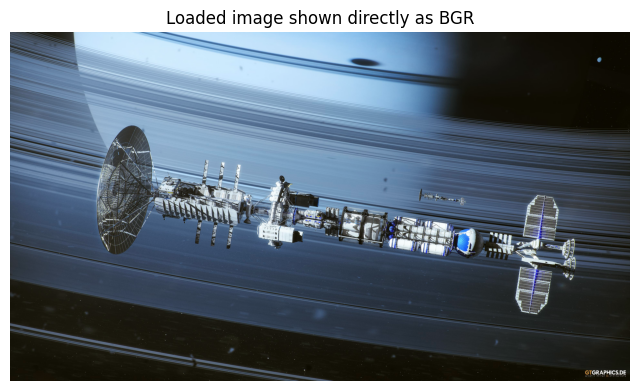

Image loaded from: ..\data\test_image_1.jpg
Image shape: (2160, 3840, 3)


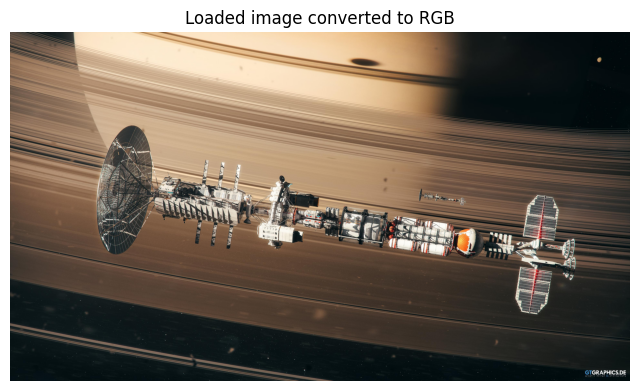

In [4]:
image_bgr = cv2.imread(str(IMAGE_PATH))

if image_bgr is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

# Show the loaded BGR image directly to make the color order visible.
plt.figure(figsize=(8, 6))
plt.imshow(image_bgr)
plt.title("Loaded image shown directly as BGR")
plt.axis("off")
plt.show()

# Convert BGR to RGB before displaying with matplotlib.
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Image loaded from: {IMAGE_PATH}")
print(f"Image shape: {image_rgb.shape}")

show_rgb(image_rgb, "Loaded image converted to RGB")

### Aufgabe 2: Datenstruktur des Bildes analysieren

Ein Bild wird in Python als NumPy-Array gespeichert. Die Form (`shape`) beschreibt die Höhe, Breite und bei Farbbildern die Anzahl der Farbkanäle.

Der Datentyp (`dtype`) zeigt, wie die einzelnen Pixelwerte gespeichert werden.

In [5]:
# Read basic image information from the NumPy array.
height, width, channels = image_bgr.shape

print(f"Height: {height} pixels")
print(f"Width: {width} pixels")
print(f"Channels: {channels}")
print(f"Data type: {image_bgr.dtype}")

Height: 2160 pixels
Width: 3840 pixels
Channels: 3
Data type: uint8


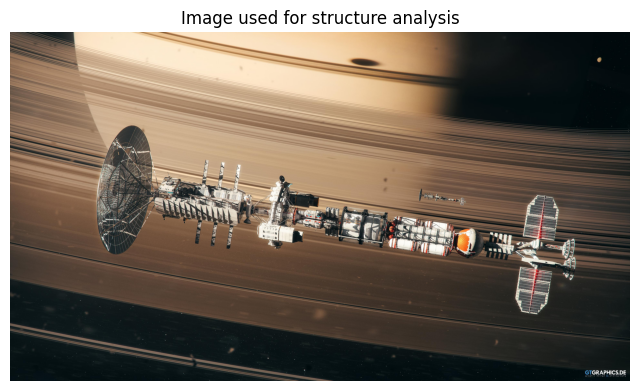

In [6]:
# Show the same image again as visual context for the printed values.
show_rgb(image_rgb, "Image used for structure analysis")

### Aufgabe 3: Einzelne Pixelwerte analysieren

Ein einzelner Pixel kann über seine Zeilen- und Spaltenposition aus dem Bildarray ausgelesen werden. Bei einem Farbbild besteht ein Pixel aus drei Werten.

Da das Bild mit OpenCV geladen wurde, sind diese Werte in der Reihenfolge BGR gespeichert: Blau, Grün, Rot.

In [7]:
# Choose one pixel near the center of the image.
row = height // 2
col = width // 2

# OpenCV stores color values as BGR.
pixel_bgr = image_bgr[row, col]
blue, green, red = pixel_bgr

print(f"Pixel position: row={row}, col={col}")
print(f"BGR pixel value: {pixel_bgr}")
print(f"Blue: {blue}, Green: {green}, Red: {red}")

Pixel position: row=1080, col=1920
BGR pixel value: [128 166 201]
Blue: 128, Green: 166, Red: 201


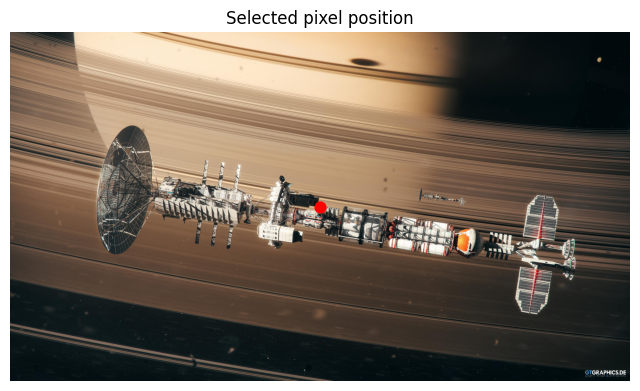

In [8]:
# Mark the selected pixel in the RGB image for easier understanding.
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.scatter(col, row, color="red", s=60)
plt.title("Selected pixel position")
plt.axis("off")
plt.show()

### Aufgabe 4: Grauwertbild erstellen

Als nächster Schritt wird das geladene Farbbild in ein Grauwertbild umgewandelt. Ein Farbbild speichert pro Pixel drei Farbwerte.

Ein Grauwertbild speichert dagegen nur einen Wert pro Pixel, nämlich die Helligkeit. Dadurch geht die Farbinformation verloren, aber Formen, Kanten und Helligkeitsunterschiede bleiben sichtbar.

In [ ]:
# Convert the OpenCV BGR image to grayscale.
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Color image shape: {image_bgr.shape}")
print(f"Grayscale image shape: {image_gray.shape}")
print(f"Grayscale data type: {image_gray.dtype}")

In [ ]:
# Show the grayscale image with a grayscale colormap.
show_gray(image_gray, "Grayscale image")

In [ ]:
# Compare the RGB image and the grayscale image side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("RGB image")
axes[0].axis("off")

axes[1].imshow(image_gray, cmap="gray")
axes[1].set_title("Grayscale image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 5: Grauwert-Histogramm erstellen

Ein Histogramm zeigt, wie oft bestimmte Pixelwerte in einem Bild vorkommen. Bei einem Grauwertbild geht es um die Intensitätswerte von 0 bis 255. Dunkle Bereiche liegen eher links im Histogramm, helle Bereiche eher rechts.

Für diese Aufgabe wird das bereits erzeugte Grauwertbild `image_gray` verwendet.

In [ ]:
# Plot the grayscale intensity distribution.
plt.figure(figsize=(8, 5))
plt.hist(image_gray.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Grayscale histogram")
plt.xlabel("Intensity value")
plt.ylabel("Pixel count")
plt.grid(alpha=0.3)
plt.show()

### Aufgabe 6: Einfache Schwellwertbildung

Bei der Schwellwertbildung wird ein Grauwertbild in ein Binärbild umgewandelt. Jeder Pixel wird mit einem festen Schwellwert verglichen. Werte über dem Schwellwert werden weiß, Werte darunter werden schwarz.

So kann ein Bild grob in Vordergrund und Hintergrund getrennt werden. Welche Bereiche als Vordergrund gelten, hängt davon ab, ob ein normales oder ein inverses Binärbild verwendet wird.

In [ ]:
# Apply a fixed threshold to the grayscale image.
threshold_value = 127
max_value = 255

_, binary_image = cv2.threshold(image_gray, threshold_value, max_value, cv2.THRESH_BINARY)
_, binary_inverse_image = cv2.threshold(image_gray, threshold_value, max_value, cv2.THRESH_BINARY_INV)

print(f"Threshold value: {threshold_value}")

Die folgenden Bilder zeigen das ursprüngliche Grauwertbild, das normale Binärbild und das inverse Binärbild im Vergleich.

In [ ]:
# Show grayscale and thresholded images side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Grayscale image")
axes[0].axis("off")

axes[1].imshow(binary_image, cmap="gray")
axes[1].set_title("Binary threshold")
axes[1].axis("off")

axes[2].imshow(binary_inverse_image, cmap="gray")
axes[2].set_title("Inverse binary threshold")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Results

Das Bild aus dem `data`-Ordner wurde mit OpenCV geladen. Für die Anzeige mit `matplotlib` wurde es von BGR nach RGB konvertiert.

Zusätzlich wurden Höhe, Breite, Anzahl der Farbkanäle und Datentyp des Bildarrays ausgegeben. Danach wurde ein einzelner Pixel aus der Bildmitte ausgelesen und als BGR-Wert betrachtet.

Das Farbbild wurde in ein Grauwertbild umgewandelt und mit `cmap="gray"` angezeigt. Anschließend wurde ein Grauwert-Histogramm mit 256 Bins für den Intensitätsbereich von 0 bis 255 erstellt.

Danach wurde ein fester Schwellwert auf das Grauwertbild angewendet. Daraus entstanden ein normales Binärbild und ein inverses Binärbild.

## Interpretation

Bei der Anzeige ist die Farbreihenfolge wichtig: OpenCV arbeitet bei Farbbildern mit BGR, `matplotlib` erwartet RGB. Deshalb muss ein geladenes OpenCV-Farbbild vor der Darstellung umgewandelt werden.

Die Bildstruktur zeigt, dass ein Farbbild als mehrdimensionales Array mit drei Kanälen vorliegt. Der Beispielpixel bestätigt diese drei Farbwerte in der Reihenfolge Blau, Grün und Rot.

Das Grauwertbild hat nur noch einen Kanal. Dieser eine Wert beschreibt die Helligkeit des jeweiligen Pixels, weshalb keine getrennten Farbkanäle mehr notwendig sind. Im Histogramm zeigen hohe Balken, welche Helligkeitswerte besonders häufig im Bild vorkommen. Werte nahe 0 stehen für dunkle Bildbereiche, Werte nahe 255 für helle Bildbereiche.

Bei der Schwellwertbildung werden Pixel nur noch in zwei Klassen eingeteilt. Im normalen Binärbild werden helle Bereiche als weiß dargestellt und können als Vordergrund interpretiert werden. Im inversen Binärbild ist es umgekehrt: dunkle Bereiche werden weiß und können dadurch als Vordergrund markiert werden.

## Conclusion

Das Bild wurde geladen, korrekt angezeigt, in seiner Grundstruktur untersucht, als Grauwertbild dargestellt, mit einem Histogramm analysiert und mit einfacher Schwellwertbildung segmentiert. Adaptive Schwellwertbildung, Otsu-Verfahren und weitere Verarbeitungsschritte folgen erst in späteren Aufgaben.

Ä, Ö und Ü werden hier nur als kurze Kodierungsprüfung genannt.